In [2]:
import gc

import numpy as np
from pyparsing import line
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score as sk_f1_score
from scipy import stats
from scipy.stats import linregress
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


import confidence_functions as cf

BASE_DIR = '/gpfs/projects/b1042/AmaralLab/shin/DNN-Decision-Uncertainty-Quantification/models'
CACHE_PATH = '/gpfs/projects/b1042/AmaralLab/shin/DNN-Decision-Uncertainty-Quantification/cached_data_224.pt'
MODEL_TAG = 'resnet18_224x224_8ep'
NUM_CLASSES = 19
CIFAR_ROOT = '/gpfs/projects/b1042/AmaralLab/shin/DNN-Decision-Uncertainty-Quantification/data'
WORKERS = 1  # for DataLoader num_workers
n_test, n_adv, n_ood = 17287, 2000, 4000


/projects/b1042/AmaralLab/shin/DNN-Decision-Uncertainty-Quantification/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"print torch version: {torch.__version__}")
print(f"Using device: {device}")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# DataLoader generator
g = torch.Generator()
g.manual_seed(SEED)

plt.rcParams.update({
    'font.size': 18,          # Global text size
    'axes.titlesize': 24,     # Plot title size
    'axes.labelsize': 18,     # X and Y label size
    'xtick.labelsize': 14,    # X-axis tick font size
    'ytick.labelsize': 14,    # Y-axis tick font size
    'legend.fontsize': 16     # Legend font size
})

print torch version: 2.13.0+cu130
Using device: cpu


## Functions

In [6]:
def compute_per_sample_f1(labels, preds, eps=1e-12):
    """
    Manual per-sample (a.k.a. 'samples'-averaged, but kept per-row) F1.
    sklearn's f1_score(..., average='samples') only returns one aggregate
    number across the dataset, not one value per sample -- this gives the
    per-row values that aggregate reduces over.
    Rows with no true positives AND no predicted positives get F1=0.0,
    matching sklearn's zero_division=0 convention (flip to 1.0 if you'd
    rather treat "correctly predicted nothing" as a perfect match).
    """
    labels = labels.astype(np.float32)
    preds = preds.astype(np.float32)

    tp = (preds * labels).sum(axis=1)
    fp = (preds * (1 - labels)).sum(axis=1)
    fn = ((1 - preds) * labels).sum(axis=1)

    denom = 2 * tp + fp + fn
    f1 = np.where(denom > 0, (2 * tp) / (denom + eps), 0.0)
    return f1

In [7]:
def scatter_plot(x, y, xlabel, ylabel, title, save_path, color='steelblue'):
    # get rrid of nan and inf in x and y
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # print if there were any NaN or inf values removed
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from scatter plot.")

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    print(f"Scatter plot: {title}")
    print(f"Slope: {slope:.2e}, R-value: {r_value:.2f}, R2: {r_value**2:.2f}, P-value: {p_value:.2e}")

    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, s=8, alpha=0.4, color=color)
    plt.plot(x, line, color="red", linewidth=2, label="Line of Best Fit")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [8]:
def scatter_plot_three_groups(x, y, n_test, n_adv, n_ood,
                               xlabel, ylabel, title, y_scale='linear', bin_num=30):
    print(f"Scatter plot: {title}")

    x_test, y_test = x[:n_test], y[:n_test]
    mask = np.isfinite(x_test) & np.isfinite(y_test)
    x_test = x_test[mask]
    y_test = y_test[mask]
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from test.")
    
    x_adv, y_adv = x[n_test:n_test + n_adv], y[n_test:n_test + n_adv]
    mask = np.isfinite(x_adv) & np.isfinite(y_adv)
    x_adv = x_adv[mask]
    y_adv = y_adv[mask]
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from adv.")
    
    x_ood, y_ood = x[n_test + n_adv:], y[n_test + n_adv:]
    mask = np.isfinite(x_ood) & np.isfinite(y_ood)
    x_ood = x_ood[mask]
    y_ood = y_ood[mask]
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from ood.")

    print(x_test.mean(), y_test.mean())
    print(x_adv.mean(), y_adv.mean())
    print(x_ood.mean(), y_ood.mean())
    print(f"print y_ood:{y_ood}, y_ood.min():{y_ood.min()}, y_ood.max():{y_ood.max()}")

    slope, intercept, r_value, p_value, _ = linregress(x_test, y_test)
    line1 = slope * x_test + intercept
    print(f"TEST DATA: Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")

    slope, intercept, r_value, p_value, _ = linregress(x_adv, y_adv)
    line2 = slope * x_adv + intercept
    print(f"ADV DATA: Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")

    # slope, intercept, r_value, p_value, _ = linregress(x_ood, y_ood)
    # line = slope * x_ood + intercept
    # print(f"OOD DATA: Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")
    
    datasets = [
    (x_ood, y_ood, 'pink', "OOD (out-of-distribution)"),
    (x_adv, y_adv, 'green', "Adversarial"),
    (x_test, y_test, 'blue', "Test (in-distribution)"), 
    ]
    
    fig, axes = plt.subplots(3, 1, figsize=(7, 15))

    for i, (ax, (x_data, y_data, color, sub_title)) in enumerate( zip(axes, datasets) ):
        if i == 0:
            # Plot 1D histogram of y_data
            ax.hist(y_data, bins=bin_num, color=color, edgecolor="black")
            ax.set_ylabel("Frequency")  # Override y-label for count histogram
            ax.set_xlabel(ylabel)  # The x-axis of the histogram represents y_data values
            ax.set_yscale(y_scale)
        else:
            # scatter plots for i == 1 and i == 2
            ax.scatter(x_data, y_data, s=10, alpha=0.2, color=color)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)

        # Line of Best Fit logic
        if i == 1:
            ax.plot(
                x_data, line2, color="red", linewidth=2, label="Line of Best Fit"
            )
            ax.legend(loc="upper left")
        elif i == 2:
            ax.plot(
                x_data, line1, color="red", linewidth=2, label="Line of Best Fit"
            )
            ax.legend(loc="upper left")
        ax.set_title(sub_title)

    fig.suptitle(title, fontsize=40)
    plt.tight_layout()
    plt.show()

    

In [9]:
def hexbin_plot_three_groups(x, y, n_test, n_adv, n_ood,
                               xlabel, ylabel, title, save_path):
    # get rrid of nan and inf in x and y
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # print if there were any NaN or inf values removed
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from scatter plot.")

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    print(f"Scatter plot: {title}")
    print(f"Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")

    x_test, y_test = x[:n_test], y[:n_test]
    x_adv, y_adv = x[n_test:n_test + n_adv], y[n_test:n_test + n_adv]
    x_ood, y_ood = x[n_test + n_adv:], y[n_test + n_adv:]

    plt.figure(figsize=(10, 5))
    plt.hexbin(x_test, y_test, bins='log', cmap='Greys', label='Test (in-distribution)')
    plt.hexbin(x_ood, y_ood, bins='log', cmap='Blues', label='OOD (out-of-distribution)')
    plt.hexbin(x_adv, y_adv, bins='log', cmap='Greens', label='Adversarial')

    (line_handle,) = plt.plot(x, line, color="red", linewidth=2, label="Line of Best Fit")
    grey_color = plt.cm.Greys(0.7)
    blue_color = plt.cm.Blues(0.7)
    green_color = plt.cm.Greens(0.7)

    # 3. Create custom patch handles using the extracted colors
    legend_handles = [
    mpatches.Patch(color=grey_color, label="Test (in-distribution)"),
    mpatches.Patch(color=blue_color, label="OOD (out-of-distribution)"),
    mpatches.Patch(color=green_color, label="Adversarial"),
    line_handle,
    ]

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout() 
    plt.show()

In [10]:
def hexbin_plot_three_subplots(x, y, n_test, n_adv, n_ood,
                               xlabel, ylabel, title, save_path):

    print(f"Scatter plot: {title}")

    x_test, y_test = x[:n_test], y[:n_test]
    mask = np.isfinite(x_test) & np.isfinite(y_test)
    x_test = x_test[mask]
    y_test = y_test[mask]
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from test.")
    
    x_adv, y_adv = x[n_test:n_test + n_adv], y[n_test:n_test + n_adv]
    mask = np.isfinite(x_adv) & np.isfinite(y_adv)
    x_adv = x_adv[mask]
    y_adv = y_adv[mask]
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from adv.")
    
    x_ood, y_ood = x[n_test + n_adv:], y[n_test + n_adv:]
    mask = np.isfinite(x_ood) & np.isfinite(y_ood)
    x_ood = x_ood[mask]
    y_ood = y_ood[mask]
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from ood.")

    print(x_test.mean(), y_test.mean())
    print(x_adv.mean(), y_adv.mean())
    print(x_ood.mean(), y_ood.mean())

    slope, intercept, r_value, p_value, _ = linregress(x_test, y_test)
    line1 = slope * x_test + intercept
    print(f"TEST DATA: Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")

    slope, intercept, r_value, p_value, _ = linregress(x_adv, y_adv)
    line2 = slope * x_adv + intercept
    print(f"ADV DATA: Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")

    # slope, intercept, r_value, p_value, _ = linregress(x_ood, y_ood)
    # line = slope * x_ood + intercept
    # print(f"OOD DATA: Slope: {slope:.4f}, R-value: {r_value:.4f}, R2: {r_value**2:.2f}, P-value: {p_value:.4f}")
    
    datasets = [
    (x_ood, y_ood, "Pinks", "OOD (out-of-distribution)"),
    (x_adv, y_adv, "Blues", "Adversarial"),
    (x_test, y_test, "Greens", "Test (in-distribution)"), 
    ]
    
    fig, axes = plt.subplots(3, 1, figsize=(5, 15))

    for i, (ax, (x_data, y_data, cmap, sub_title)) in enumerate( zip(axes, datasets) ):
        if i == 0:
            # Plot 1D histogram of y_data
            ax.hist(y_data, bins=30, color="pink", edgecolor="black")
            ax.set_ylabel("Frequency")  # Override y-label for count histogram
            ax.set_xlabel(ylabel)  # The x-axis of the histogram represents y_data values
        else:
            # Hexbin plots for i == 1 and i == 2
            # intense_norm = mcolors.PowerNorm(gamma=0.2)
            ax.hexbin(x_data, y_data, bins='log', cmap=cmap)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)

        # Line of Best Fit logic
        if i == 1:
            ax.plot(
                x_data, line2, color="red", linewidth=2, label="Line of Best Fit"
            )
            ax.legend(loc="upper left")
        elif i == 2:
            ax.plot(
                x_data, line1, color="red", linewidth=2, label="Line of Best Fit"
            )
            ax.legend(loc="upper left")
        ax.set_title(sub_title)

    fig.suptitle(title, fontsize=30)
    plt.tight_layout()
    plt.show()

In [11]:
# make box plot for in distribution vs vs adversarial vs out of distribution for mean above threshold prob, stability, and mahalanobis
def box_plot_three_groups(x, n_test, n_adv, n_ood, xlabel, title, save_path):
    # get rrid of nan and inf in x
    mask = np.isfinite(x)
    x = x[mask]

    # print if there were any NaN or inf values removed
    n_removed = len(mask) - np.sum(mask)
    print(f"Removed {n_removed} samples with NaN or inf values from box plot.")

    plt.figure(figsize=(6, 5))
    x_test, x_adv, x_ood = x[:n_test], x[n_test:n_test + n_adv], x[n_test + n_adv:]

    plt.boxplot([x_test, x_adv, x_ood], tick_labels=['ID', 'Adversarial', 'OOD'])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [12]:
prob = torch.load(f'{BASE_DIR}/sigmoid_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['prob']
test_labels = torch.load(f'{BASE_DIR}/test_labels_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['test_labels']
stability = torch.load(f'{BASE_DIR}/stability_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['stability']
threshold = np.asarray(torch.load(f'{BASE_DIR}/threshold_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['threshold'])
stats_maha = torch.load(f'{BASE_DIR}/stats_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['stats']

prob_np = prob.numpy() if torch.is_tensor(prob) else np.asarray(prob)
labels_np = test_labels.numpy() if torch.is_tensor(test_labels) else np.asarray(test_labels)
stability_np = stability.numpy() if torch.is_tensor(stability) else np.asarray(stability)

preds_np = (prob_np > threshold).astype(np.float32)
f1_per_sample = compute_per_sample_f1(labels_np, preds_np)


## ID plots

In [89]:
# mean sigmoid prob among classes ABOVE threshold, per sample
above_thresh_mask = prob_np > threshold
mean_prob_above = np.full(len(prob_np), np.nan)
for i in range(len(prob_np)):
    vals = prob_np[i][above_thresh_mask[i]]
    if len(vals) > 0:
        mean_prob_above[i] = vals.mean()

Removed 2162 samples with NaN or inf values from scatter plot.
Scatter plot: F1 vs Sigmoid Prob
Slope: 3.04e-01, R-value: 0.49, R2: 0.24, P-value: 0.00e+00


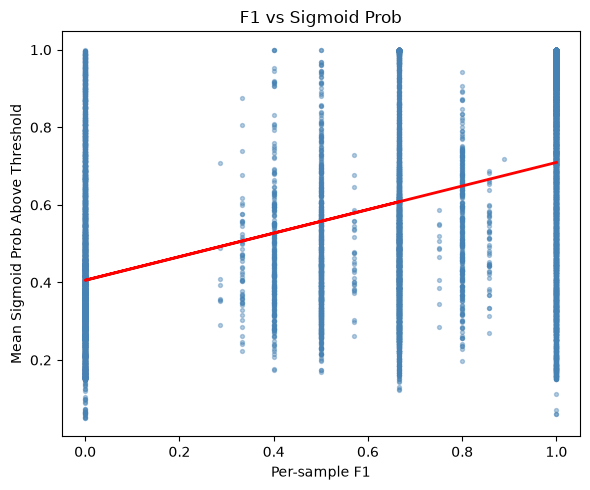

Removed 0 samples with NaN or inf values from scatter plot.
Scatter plot: F1 vs Entropy From Training
Slope: -9.44e-04, R-value: -0.03, R2: 0.00, P-value: 3.61e-04


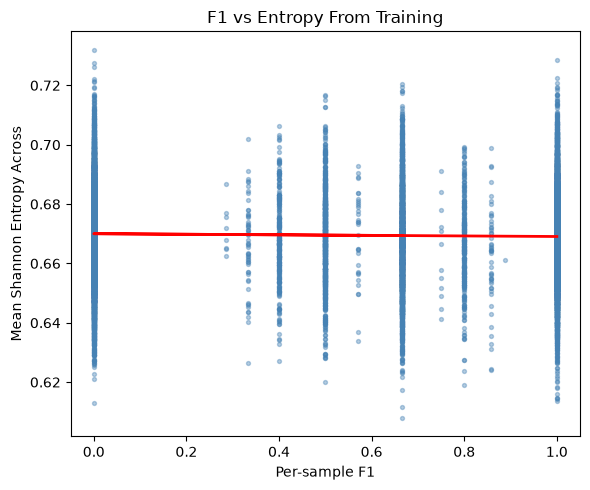

In [95]:
scatter_plot(
    f1_per_sample, mean_prob_above,
    xlabel="Per-sample F1", ylabel="Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid Prob",
    save_path=f'{BASE_DIR}/f1_vs_mean_prob.png'
)


scatter_plot(
    f1_per_sample, stability_np,
    xlabel="Per-sample F1", ylabel="Mean Shannon Entropy Across",
    title="F1 vs Entropy From Training",
    save_path=f'{BASE_DIR}/f1_vs_shannon.png'
)

In [21]:
del prob, test_labels, stability, preds_np, above_thresh_mask, mean_prob_above
gc.collect() 

2750

## Maha and OOD

### Loading things

In [14]:
alpha = torch.load(f'{BASE_DIR}/alpha_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['alpha']
alpha

[array([ 0.39444256, -1.95087627,  0.50577105, -2.08852942]),
 1.8311072467855871]

In [15]:
f1_combined = torch.load(f'{BASE_DIR}/f1_combined_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['f1_combined']
mean_prob_combined = torch.load(f'{BASE_DIR}/mean_prob_combined_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['mean_prob_combined']
stability_combined_np = torch.load(f'{BASE_DIR}/stability_combined_np_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['stability_combined_np']

In [16]:
maha_combined_np = torch.load(f'{BASE_DIR}/maha_combined_np_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['maha_combined_np']
maha_combined_np

array([0.4366977 , 0.80865658, 0.86189358, ..., 0.2128075 , 0.2128075 ,
       0.2128075 ], shape=(23287,))

In [17]:
import importlib
importlib.reload(cf)

<module 'confidence_functions' from '/gpfs/projects/b1042/AmaralLab/shin/DNN-Decision-Uncertainty-Quantification/confidence_functions.py'>

### Scatter plot three goups

Scatter plot: F1 vs Sigmoid
Removed 2158 samples with NaN or inf values from test.
Removed 160 samples with NaN or inf values from adv.
Removed 18 samples with NaN or inf values from ood.
0.5896508 0.5848130668778241
0.098938935 0.6642331009487743
0.0 0.7694020948701621
print y_ood:[0.65067917 0.95594382 0.64866012 ... 0.92168504 0.7407704  0.68727207], y_ood.min():0.23676207661628723, y_ood.max():0.997708261013031
TEST DATA: Slope: 0.3036, R-value: 0.4908, R2: 0.24, P-value: 0.0000
ADV DATA: Slope: 0.0789, R-value: 0.0787, R2: 0.01, P-value: 0.0007


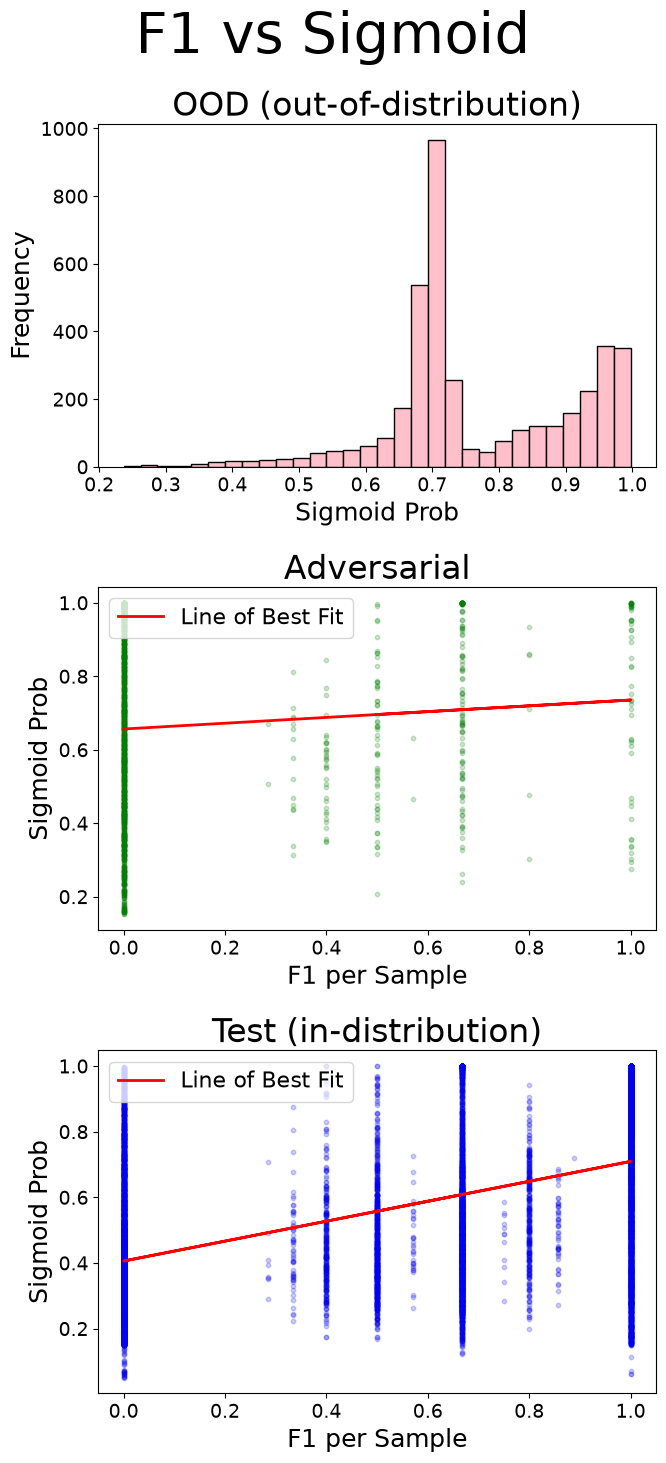

Scatter plot: F1 vs Entropy
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.8254098
0.09102381 0.8481287
0.0 0.86689365
print y_ood:[0.78547424 0.89674646 0.83186454 ... 0.89317673 0.8641802  0.8503302 ], y_ood.min():0.7268323302268982, y_ood.max():0.9642954468727112
TEST DATA: Slope: 0.0896, R-value: 0.5029, R2: 0.25, P-value: 0.0000
ADV DATA: Slope: 0.0058, R-value: 0.0182, R2: 0.00, P-value: 0.4156


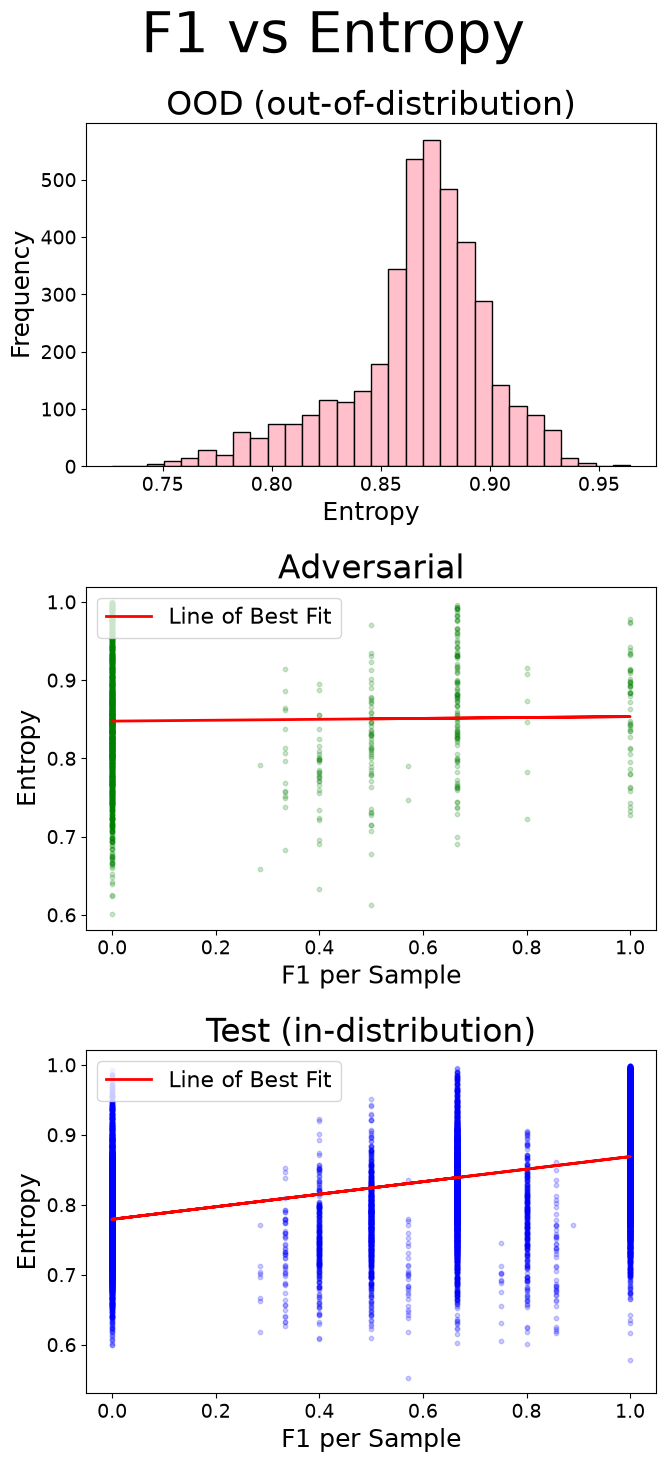

Scatter plot: F1 vs Mahalanobis
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.6616484935469574
0.09102381 0.44789870406912896
0.0 0.21280749627946405
print y_ood:[0.2128075 0.2128075 0.2128075 ... 0.2128075 0.2128075 0.2128075], y_ood.min():0.21280749627946413, y_ood.max():0.21280749627946413
TEST DATA: Slope: -0.1008, R-value: -0.1784, R2: 0.03, P-value: 0.0000
ADV DATA: Slope: -0.0933, R-value: -0.0978, R2: 0.01, P-value: 0.0000


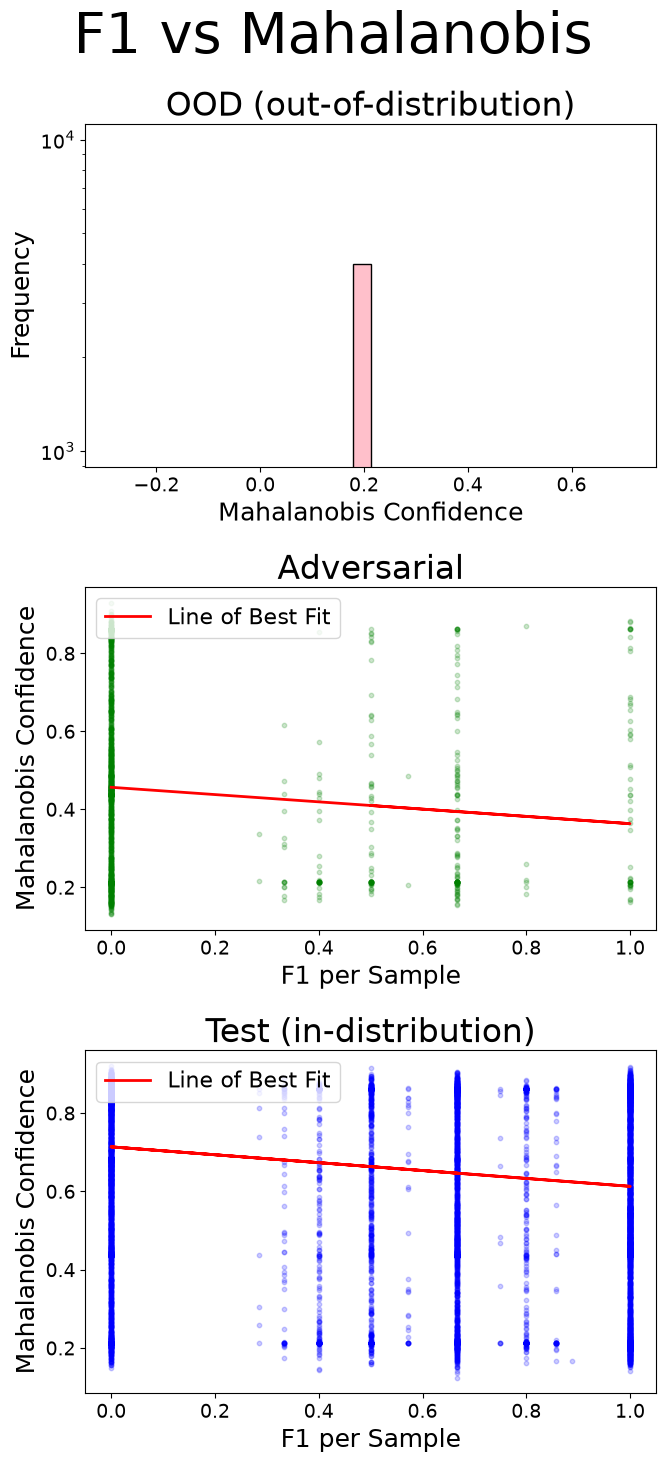

In [217]:
scatter_plot_three_groups(
    f1_combined, mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Sigmoid Prob",
    # title="F1 vs Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid",
)

scatter_plot_three_groups(
    f1_combined, stability_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Entropy",
    # title="F1 vs Entropy from Sigmoid Prob",
    title="F1 vs Entropy",
)

scatter_plot_three_groups(
    f1_combined, maha_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mahalanobis Confidence",
    title="F1 vs Mahalanobis",
    y_scale='log'
)

### Hexbin plot three groups

Removed 2336 samples with NaN or inf values from scatter plot.
Scatter plot: F1 vs Sigmoid Prob
Slope: 0.1115, R-value: 0.1962, R2: 0.04, P-value: 0.0000


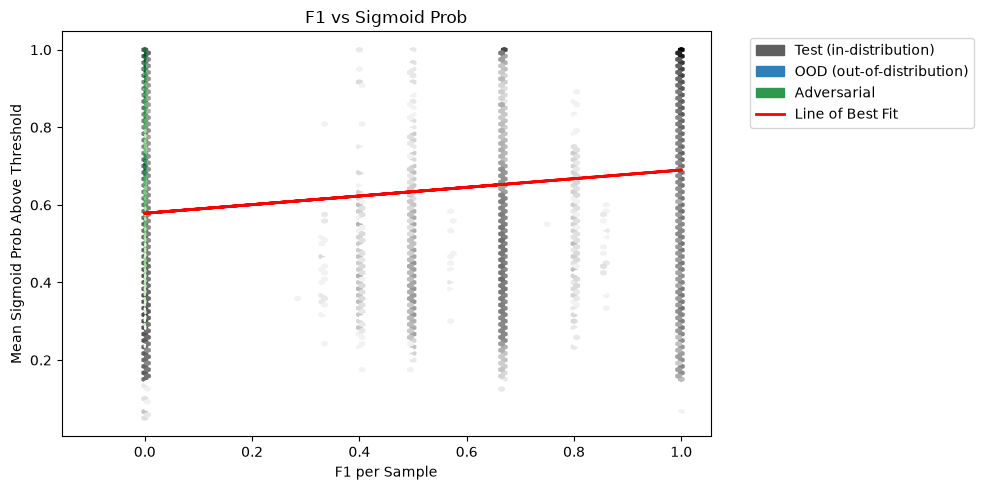

Removed 0 samples with NaN or inf values from scatter plot.
Scatter plot: F1 vs Entropy from Sigmoid Prob
Slope: 0.0492, R-value: 0.2926, R2: 0.09, P-value: 0.0000


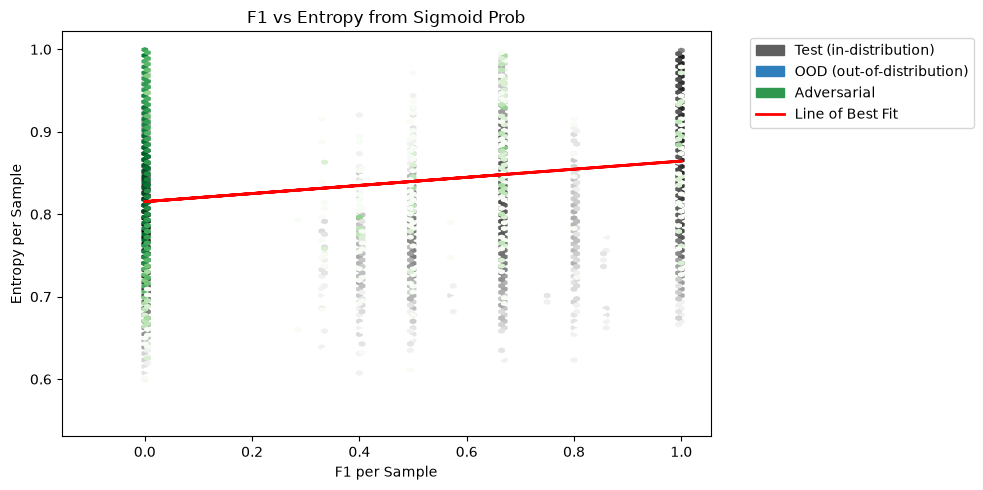

Removed 0 samples with NaN or inf values from scatter plot.
Scatter plot: F1 vs Mahalanobis Confidence
Slope: 0.1060, R-value: 0.1656, R2: 0.03, P-value: 0.0000


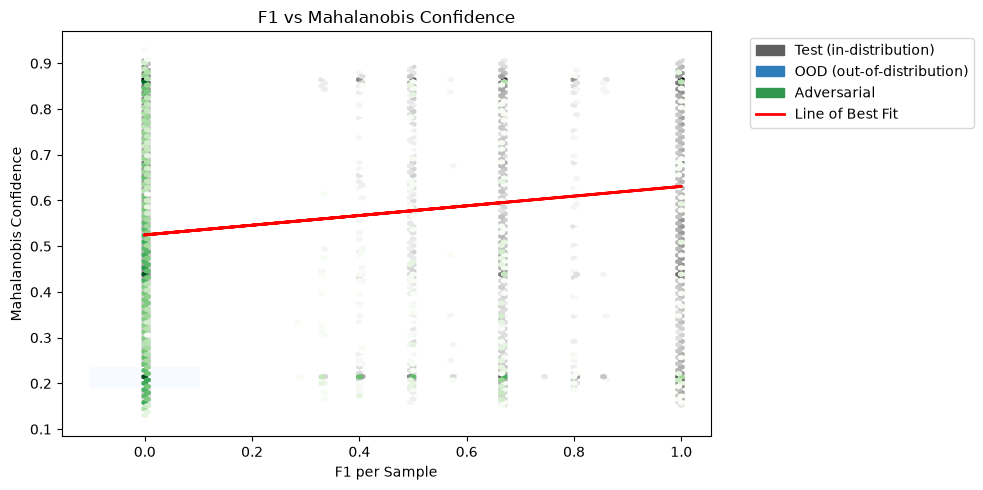

In [93]:
hexbin_plot_three_groups(
    f1_combined, mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid Prob",
    save_path=f'{BASE_DIR}/f1_vs_mean_prob_combined.png'
)

hexbin_plot_three_groups(
    f1_combined, stability_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Entropy per Sample",
    title="F1 vs Entropy from Sigmoid Prob",
    save_path=f'{BASE_DIR}/f1_vs_stability_combined.png'
)

hexbin_plot_three_groups(
    f1_combined, maha_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mahalanobis Confidence",
    title="F1 vs Mahalanobis Confidence",
    save_path=f'{BASE_DIR}/f1_vs_mahalanobis_combined.png'
)

### Checking test, adv, OOD dataset

In [51]:
x_test, y_test = f1_combined[:n_test], mean_prob_combined[:n_test]
mask = np.isfinite(x_test) & np.isfinite(y_test)
x_test = x_test[mask]
y_test = y_test[mask]

print(x_test.mean(), y_test.mean())

0.5896508 0.5848130668778241


In [ ]:
x_adv, y_adv = f1_combined[n_test:n_test + n_adv], mean_prob_combined[n_test:n_test + n_adv]
mask = np.isfinite(x_adv) & np.isfinite(y_adv)
x_adv = x_adv[mask]
y_adv = y_adv[mask]

print(x_adv.mean(), y_adv.mean())

slope, intercept, r_value, p_value, std_err = linregress(x_adv, y_adv)
slope
r_value**2

0.098938935 0.6642331009487743


np.float64(0.006189120994424751)

In [53]:
x_ood, y_ood = f1_combined[n_test + n_adv:], mean_prob_combined[n_test + n_adv:]
mask = np.isfinite(x_ood) & np.isfinite(y_ood)
x_ood = x_ood[mask]
y_ood = y_ood[mask]

print(x_ood.mean(), y_ood.mean())

0.0 0.7694020948701621


### Hexbin plot three subplots

Scatter plot: F1 vs Sigmoid
Removed 2158 samples with NaN or inf values from test.
Removed 160 samples with NaN or inf values from adv.
Removed 18 samples with NaN or inf values from ood.
0.5896508 0.5848130668778241
0.098938935 0.6642331009487743
0.0 0.7694020948701621
TEST DATA: Slope: 0.3036, R-value: 0.4908, R2: 0.24, P-value: 0.0000
ADV DATA: Slope: 0.0789, R-value: 0.0787, R2: 0.01, P-value: 0.0007


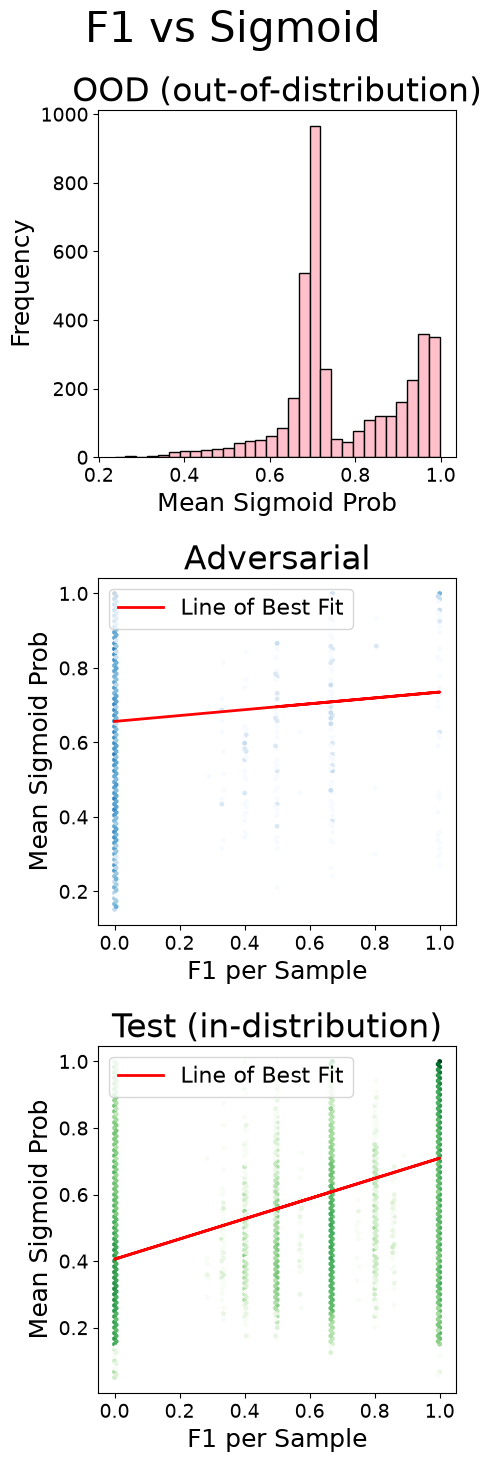

Scatter plot: F1 vs Entropy
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.8254098
0.09102381 0.8481287
0.0 0.86689365
TEST DATA: Slope: 0.0896, R-value: 0.5029, R2: 0.25, P-value: 0.0000
ADV DATA: Slope: 0.0058, R-value: 0.0182, R2: 0.00, P-value: 0.4156


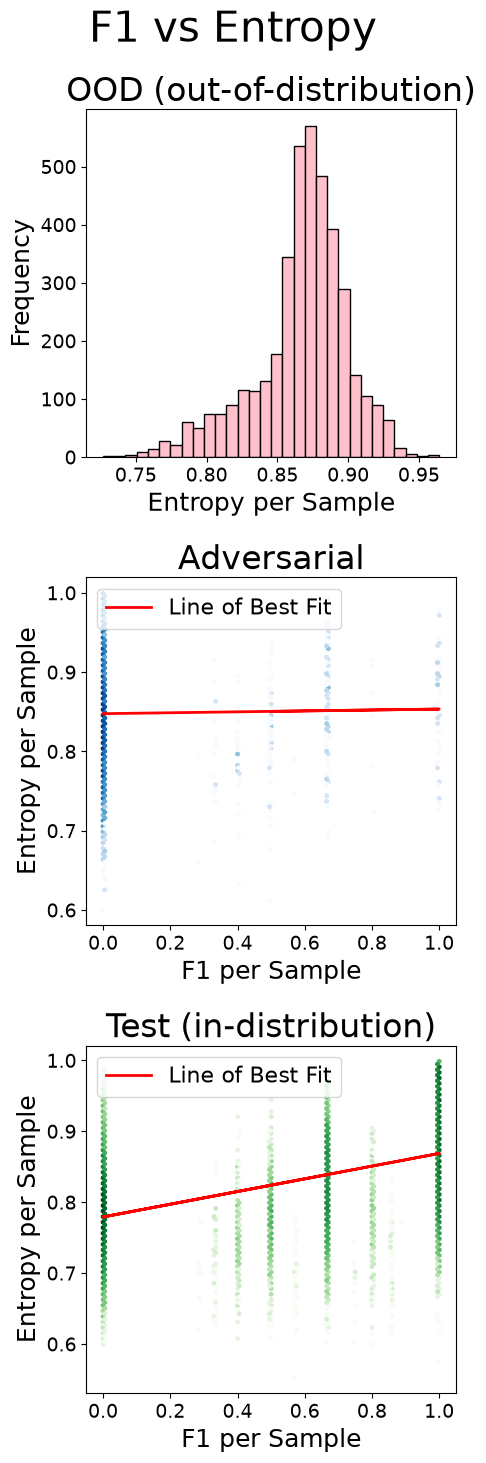

Scatter plot: F1 vs Mahalanobis
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.6616484935469574
0.09102381 0.44789870406912896
0.0 0.21280749627946405
TEST DATA: Slope: -0.1008, R-value: -0.1784, R2: 0.03, P-value: 0.0000
ADV DATA: Slope: -0.0933, R-value: -0.0978, R2: 0.01, P-value: 0.0000


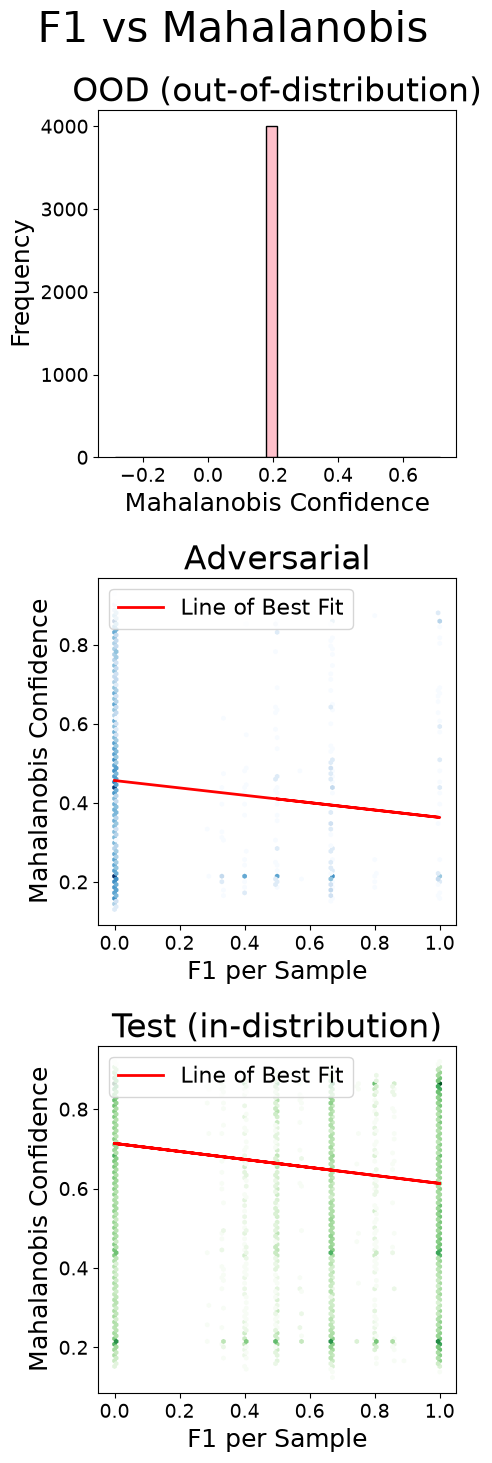

In [200]:
hexbin_plot_three_subplots(
    f1_combined, mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mean Sigmoid Prob",
    # title="F1 vs Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid",
    save_path=f'{BASE_DIR}/f1_vs_mean_prob_combined.png'
)

hexbin_plot_three_subplots(
    f1_combined, stability_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Entropy per Sample",
    # title="F1 vs Entropy from Sigmoid Prob",
    title="F1 vs Entropy",
    save_path=f'{BASE_DIR}/f1_vs_stability_combined.png'
)

hexbin_plot_three_subplots(
    f1_combined, maha_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mahalanobis Confidence",
    # title="F1 vs Mahalanobis Confidence",
    title="F1 vs Mahalanobis",
    save_path=f'{BASE_DIR}/f1_vs_mahalanobis_combined.png'
)

### Box plot three groups

Removed 2336 samples with NaN or inf values from box plot.


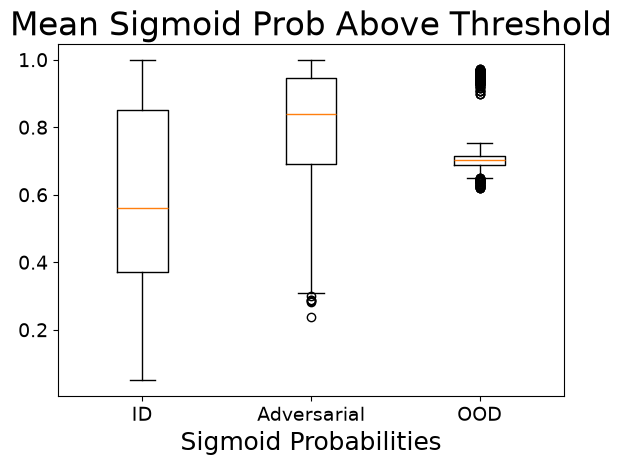

Removed 0 samples with NaN or inf values from box plot.


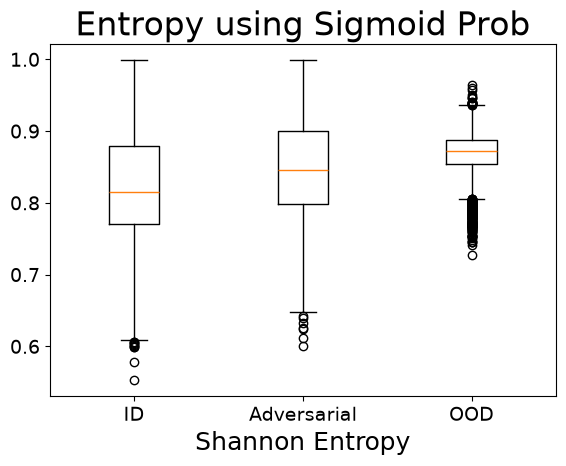

Removed 0 samples with NaN or inf values from box plot.


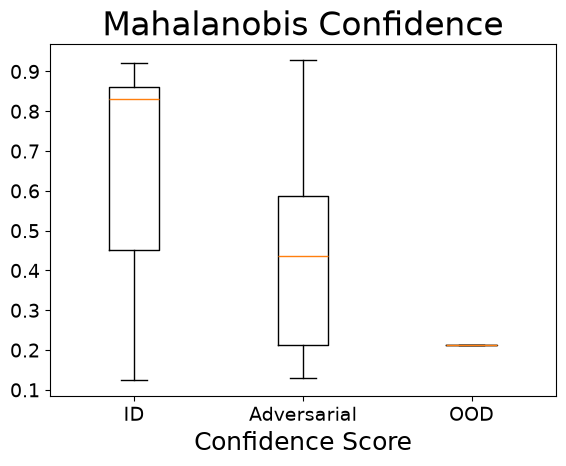

In [129]:
box_plot_three_groups(
    mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="Sigmoid Probabilities",
    title="Mean Sigmoid Prob Above Threshold",
    save_path=f'{BASE_DIR}/box_mean_prob_combined.png'
)

box_plot_three_groups(
    stability_combined_np, n_test, n_adv, n_ood,
    xlabel="Shannon Entropy",
    title="Entropy using Sigmoid Prob",
    save_path=f'{BASE_DIR}/box_stability_combined.png'
)

box_plot_three_groups(
    maha_combined_np, n_test, n_adv, n_ood,
    xlabel="Confidence Score",
    title="Mahalanobis Confidence",
    save_path=f'{BASE_DIR}/box_mahalanobis_combined.png'
)

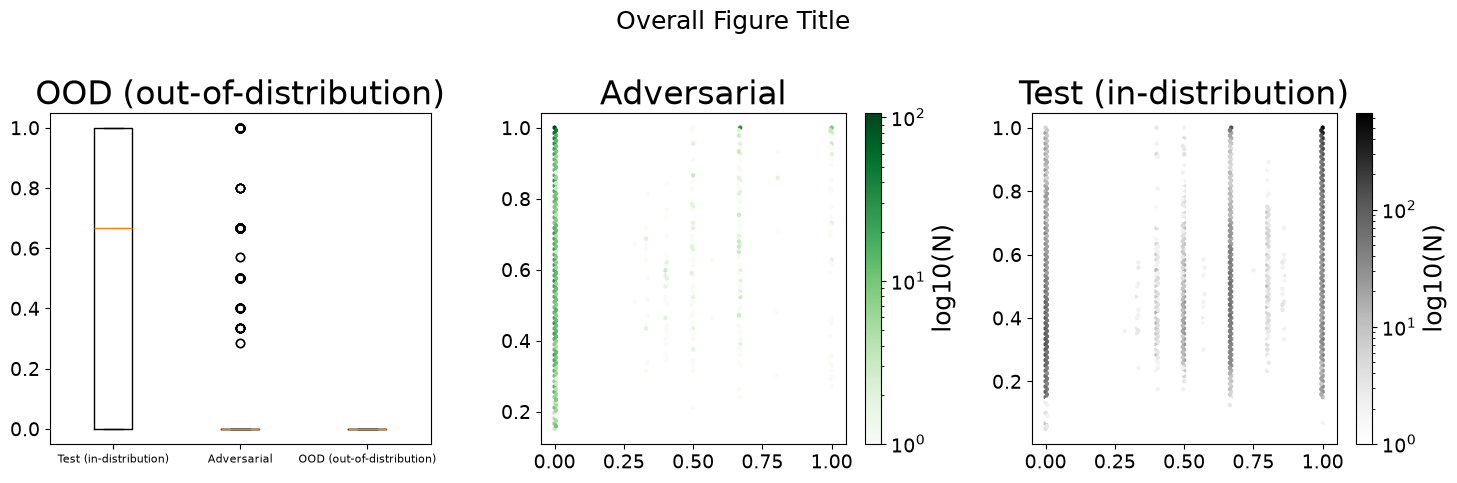

In [113]:
# Create figure with a larger overall title font size
datasets = [
    (x_ood, y_ood, "Blues", "OOD (out-of-distribution)"),
    (x_adv, y_adv, "Greens", "Adversarial"),
    (x_test, y_test, "Greys", "Test (in-distribution)"), 
    ]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Overall Figure Title", fontsize=18)  # Adjust size here (e.g., 18 or 20)

for i, (ax, (x_data, y_data, cmap, sub_title)) in enumerate(
    zip(axes, datasets)
):
    if i == 0:
        # Boxplot with tick labels
        ax.boxplot(
            [x_test, x_adv, x_ood],
            tick_labels=[
                "Test (in-distribution)",
                "Adversarial",
                "OOD (out-of-distribution)",
            ],
        )

        # Make x-axis tick labels smaller
        ax.tick_params(axis="x", labelsize=8)  # Adjust size here (e.g., 8 or 9)

        # Optional: rotate if labels still overlap
        # ax.tick_params(axis='x', labelsize=8, rotation=15)
    else:
        hb = ax.hexbin(x_data, y_data, bins="log", cmap=cmap, mincnt=1)
        fig.colorbar(hb, ax=ax, label="log10(N)")

    ax.set_title(sub_title)

plt.tight_layout()
plt.show()

### Box plot nine plots

In [134]:
import pandas as pd
import seaborn as sns

# Helper function to remove NaN/Inf and slice groups
def clean_and_split(x, n_test, n_adv, n_ood):
    mask = np.isfinite(x)
    x = x[mask]
    return x[:n_test], x[n_test:n_test + n_adv], x[n_test + n_adv:]

group_labels = (['Test (in-distribution)'] * n_test + 
                ['Adversarial'] * n_adv + 
                ['OOD (out-of-distribution)'] * n_ood)

p_test, p_adv, p_ood = clean_and_split(mean_prob_combined, n_test, n_adv, n_ood)
s_test, s_adv, s_ood = clean_and_split(stability_combined_np, n_test, n_adv, n_ood)
m_test, m_adv, m_ood = clean_and_split(maha_combined_np, n_test, n_adv, n_ood)

df = pd.DataFrame({
    'Group': group_labels,
    'Mean Probability': np.concatenate([p_test, p_adv, p_ood]),
    'Shannon Stability': np.concatenate([s_test, s_adv, s_ood]),
    'Mahalanobis Confidence': np.concatenate([m_test, m_adv, m_ood])
})

# Reshape into Tidy Format
df_melted = pd.melt(df, id_vars=['Group'], var_name='Metric', value_name='Value')

palette = {'Test (in-distribution)': '#2b5c8f', 'Adversarial': '#d95f02', 'OOD (out-of-distribution)': '#7570b3'}

g = sns.catplot(
    data=df_melted,
    x='Methods',
    y='Confidence',
    col='Metric',
    hue='Data Group',
    kind='box',
    palette=palette,
    sharey=False,  # Allows independent Y-scales per metric
    height=4,
    aspect=1.0,
    dodge=False
)

g.set_xticklabels(rotation=15)
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/combined_box_plots_subplots.png', dpi=150)



# everything on a single axis for easier comparison of distributions across metrics
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_melted,
    x='Metric',
    y='Value',
    hue='Group',
    palette=['#2b5c8f', '#d95f02', '#7570b3']
)

plt.title('Distribution Comparison across Metrics', fontsize=24)
plt.xlabel('Metric', fontsize=18)
plt.ylabel('Value', fontsize=18)
plt.legend(title='Dataset Group', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

## Load Cifar10

In [ ]:
cifar_image = cf.get_cifar10_ood_loader(root=CIFAR_ROOT, batch_size=500, download=True, num_workers=WORKERS, trans=False)
img, lab = cifar_image[1]
plt.imshow(img)
plt.axis('off') # Hide axes ticks
plt.show()

## adv_alpha

In [206]:
maha_combined_adv_np = torch.load(f'{BASE_DIR}/maha_combined_np_alpha_adv_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['maha_combined_np']
maha_combined_adv_np

array([0.45967597, 0.78401414, 0.82809067, ..., 0.54671977, 0.54671977,
       0.54671977], shape=(23287,))

Scatter plot: F1 vs Sigmoid
Removed 2158 samples with NaN or inf values from test.
Removed 160 samples with NaN or inf values from adv.
Removed 18 samples with NaN or inf values from ood.
0.5896508 0.5848130668778241
0.098938935 0.6642331009487743
0.0 0.7694020948701621
print y_ood:[0.65067917 0.95594382 0.64866012 ... 0.92168504 0.7407704  0.68727207], y_ood.min():0.23676207661628723, y_ood.max():0.997708261013031
TEST DATA: Slope: 0.3036, R-value: 0.4908, R2: 0.24, P-value: 0.0000
ADV DATA: Slope: 0.0789, R-value: 0.0787, R2: 0.01, P-value: 0.0007


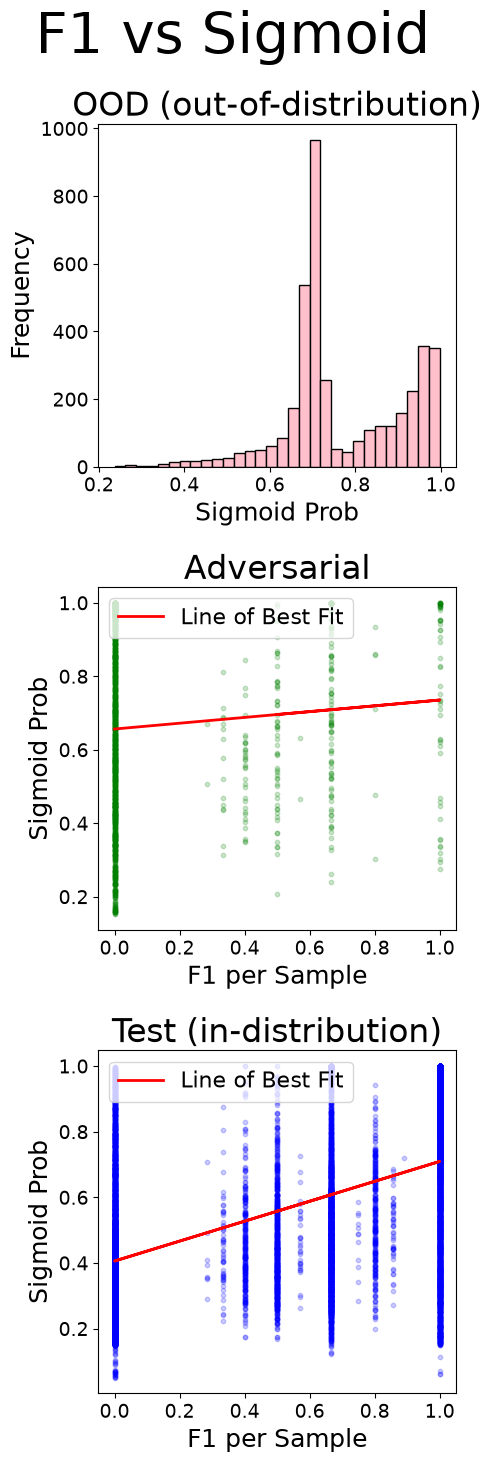

Scatter plot: F1 vs Entropy
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.8254098
0.09102381 0.8481287
0.0 0.86689365
print y_ood:[0.78547424 0.89674646 0.83186454 ... 0.89317673 0.8641802  0.8503302 ], y_ood.min():0.7268323302268982, y_ood.max():0.9642954468727112
TEST DATA: Slope: 0.0896, R-value: 0.5029, R2: 0.25, P-value: 0.0000
ADV DATA: Slope: 0.0058, R-value: 0.0182, R2: 0.00, P-value: 0.4156


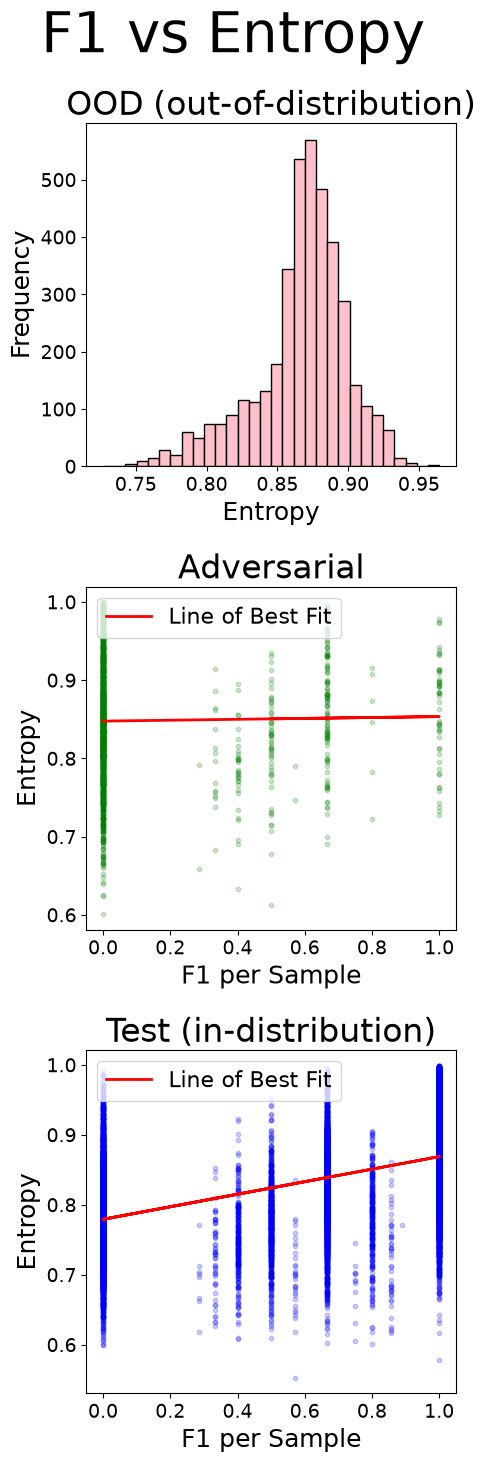

Scatter plot: F1 vs Mahalanobis
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.7188357808323268
0.09102381 0.5509485716018405
0.0 0.5467197743443455
print y_ood:[0.54671977 0.54671977 0.54671977 ... 0.54671977 0.54671977 0.54671977], y_ood.min():0.5467197743443456, y_ood.max():0.5467197743443457
TEST DATA: Slope: -0.0775, R-value: -0.2141, R2: 0.05, P-value: 0.0000
ADV DATA: Slope: 0.0079, R-value: 0.0109, R2: 0.00, P-value: 0.6266


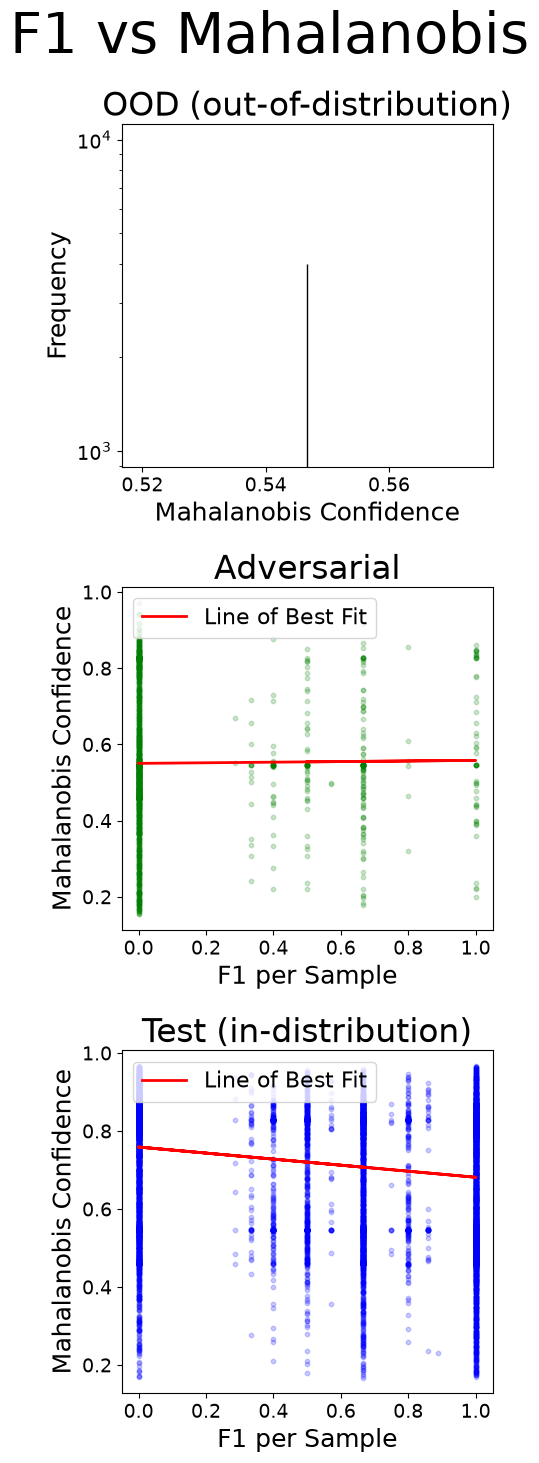

In [215]:
scatter_plot_three_groups(
    f1_combined, mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Sigmoid Prob",
    # title="F1 vs Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid",
)

scatter_plot_three_groups(
    f1_combined, stability_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Entropy",
    # title="F1 vs Entropy from Sigmoid Prob",
    title="F1 vs Entropy",
)

scatter_plot_three_groups(
    f1_combined, maha_combined_adv_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mahalanobis Confidence",
    title="F1 vs Mahalanobis",
    bin_num=1, y_scale='log'
)

# Sigmoid not chi2.cdf

In [18]:
maha_combined_np_sig = torch.load(f'{BASE_DIR}/maha_combined_np_sig_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['maha_combined_np']
maha_combined_np_sig

array([5.82694530e-01, 6.83956444e-01, 7.89918840e-01, ...,
       2.52821982e-33, 3.27526682e-34, 1.45051705e-33],
      shape=(23287,), dtype=float32)

Scatter plot: F1 vs Sigmoid
Removed 2158 samples with NaN or inf values from test.
Removed 160 samples with NaN or inf values from adv.
Removed 18 samples with NaN or inf values from ood.
0.5896508 0.5848130668778241
0.098938935 0.6642331009487743
0.0 0.7694020948701621
print y_ood:[0.65067917 0.95594382 0.64866012 ... 0.92168504 0.7407704  0.68727207], y_ood.min():0.23676207661628723, y_ood.max():0.997708261013031
TEST DATA: Slope: 0.3036, R-value: 0.4908, R2: 0.24, P-value: 0.0000
ADV DATA: Slope: 0.0789, R-value: 0.0787, R2: 0.01, P-value: 0.0007


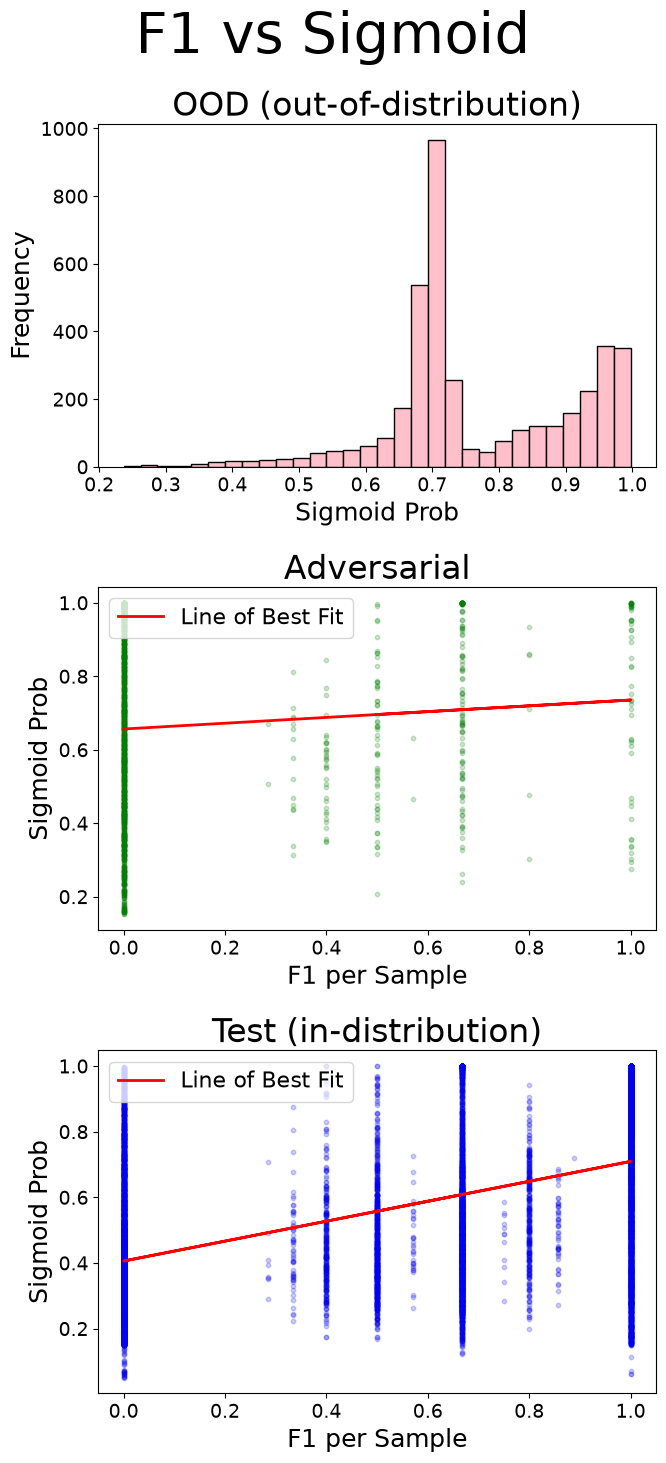

Scatter plot: F1 vs Entropy
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.8254098
0.09102381 0.8481287
0.0 0.86689365
print y_ood:[0.78547424 0.89674646 0.83186454 ... 0.89317673 0.8641802  0.8503302 ], y_ood.min():0.7268323302268982, y_ood.max():0.9642954468727112
TEST DATA: Slope: 0.0896, R-value: 0.5029, R2: 0.25, P-value: 0.0000
ADV DATA: Slope: 0.0058, R-value: 0.0182, R2: 0.00, P-value: 0.4156


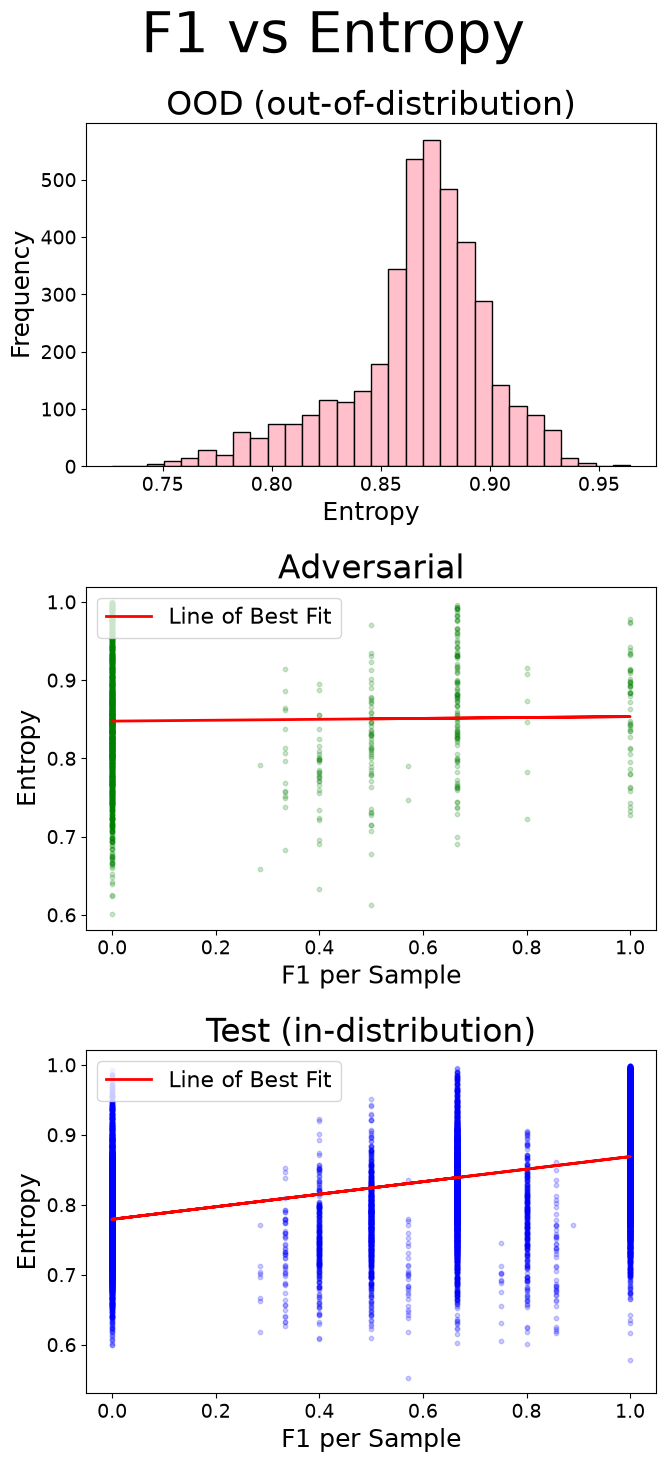

Scatter plot: F1 vs Mahalanobis
Removed 0 samples with NaN or inf values from test.
Removed 0 samples with NaN or inf values from adv.
Removed 0 samples with NaN or inf values from ood.
0.51604253 0.71234447
0.09102381 0.548947
0.0 0.0009053438
print y_ood:[1.66745449e-04 6.44128040e-09 9.33204376e-07 ... 2.52821982e-33
 3.27526682e-34 1.45051705e-33], y_ood.min():3.5861539844538205e-38, y_ood.max():0.5442515015602112
TEST DATA: Slope: -0.0747, R-value: -0.2435, R2: 0.06, P-value: 0.0000
ADV DATA: Slope: 0.0154, R-value: 0.0182, R2: 0.00, P-value: 0.4148


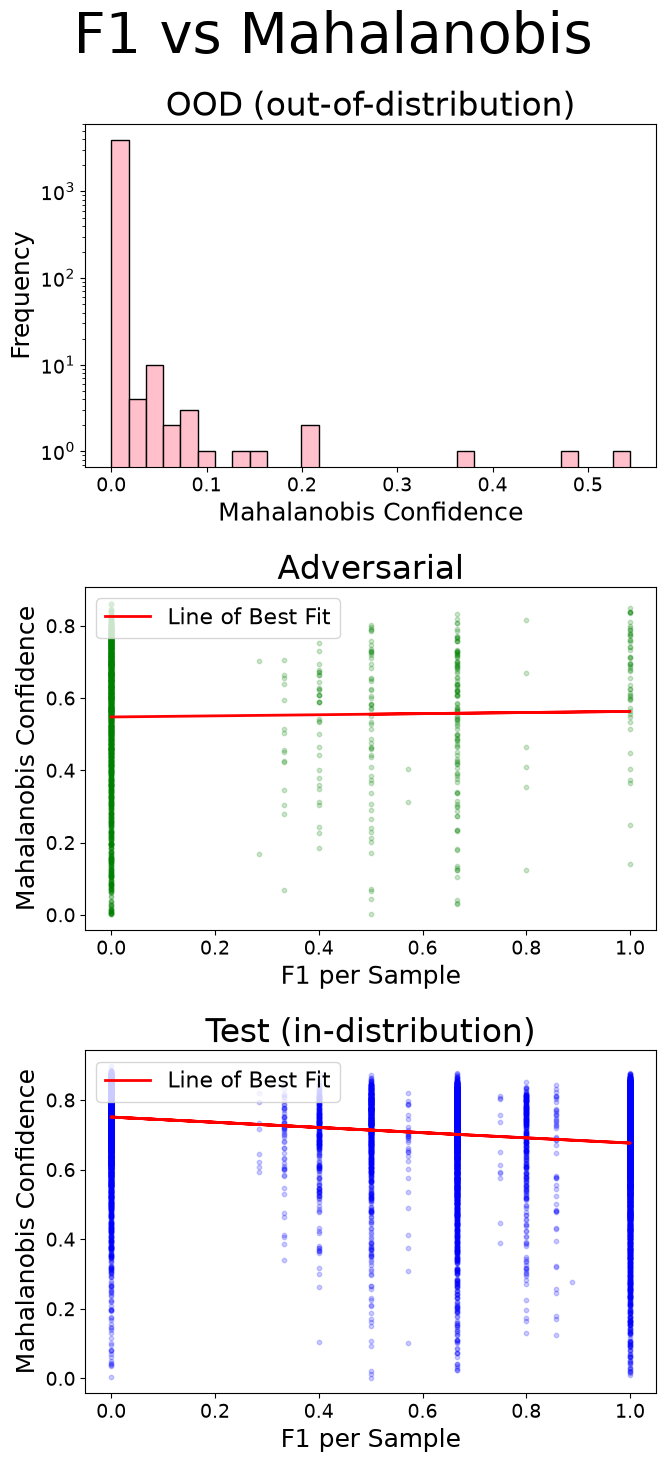

In [20]:
scatter_plot_three_groups(
    f1_combined, mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Sigmoid Prob",
    # title="F1 vs Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid",
)

scatter_plot_three_groups(
    f1_combined, stability_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Entropy",
    # title="F1 vs Entropy from Sigmoid Prob",
    title="F1 vs Entropy",
)

scatter_plot_three_groups(
    f1_combined, maha_combined_np_sig, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mahalanobis Confidence",
    title="F1 vs Mahalanobis",
    bin_num=30, y_scale='log'
)

## sigmoid not chi2 and avd data only

In [2]:
maha_combined_np_alpha_adv_sig = torch.load(f'{BASE_DIR}/maha_combined_np_alpha_adv_sig_{MODEL_TAG}.pt', map_location='cpu', weights_only=False)['maha_combined_np']
maha_combined_np_alpha_adv_sig

NameError: name 'torch' is not defined

In [1]:
scatter_plot_three_groups(
    f1_combined, mean_prob_combined, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Sigmoid Prob",
    # title="F1 vs Mean Sigmoid Prob Above Threshold",
    title="F1 vs Sigmoid",
)

scatter_plot_three_groups(
    f1_combined, stability_combined_np, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Entropy",
    # title="F1 vs Entropy from Sigmoid Prob",
    title="F1 vs Entropy",
)

scatter_plot_three_groups(
    f1_combined, maha_combined_np_alpha_adv_sig, n_test, n_adv, n_ood,
    xlabel="F1 per Sample", ylabel="Mahalanobis Confidence",
    title="F1 vs Mahalanobis",
    bin_num=1, y_scale='log'
)

NameError: name 'scatter_plot_three_groups' is not defined